 Uploader le ZIP

In [ ]:
from google.colab import files
uploaded = files.upload()  # sélectionne ton fichier dataset_vehicules.zip

Saving dataset_vehicules.zip to dataset_vehicules (1).zip


In [ ]:
import os, shutil, zipfile

# Supprimer le dataset actuel
if os.path.exists("dataset"):
    shutil.rmtree("dataset")

# Restaurer depuis le ZIP original
with zipfile.ZipFile("dataset_vehicules.zip", "r") as z:
    z.extractall("dataset")

print("Dataset original restauré !")
for genre in ["voiture", "moto", "bus", "camion"]:
    n = len(os.listdir(f"dataset/{genre}"))
    print(f"  {genre}: {n} images")

Dataset original restauré !
  voiture: 2442 images
  moto: 204 images
  bus: 241 images
  camion: 291 images


# **equilibrage de dataset à 200 images pour chaque categorie**

In [ ]:
import os, random

LIMITE = 200

for genre in ["voiture", "moto", "bus", "camion"]:
    dossier  = f"dataset/{genre}"
    fichiers = os.listdir(dossier)
    if len(fichiers) > LIMITE:
        a_supprimer = random.sample(fichiers, len(fichiers) - LIMITE)
        for f in a_supprimer:
            os.remove(f"{dossier}/{f}")

print("Dataset équilibré !")
for genre in ["voiture", "moto", "bus", "camion"]:
    n = len(os.listdir(f"dataset/{genre}"))
    print(f"  {genre}: {n} images")

Dataset équilibré !
  voiture: 200 images
  moto: 200 images
  bus: 200 images
  camion: 200 images


# **chargement** de dataset

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentation forte pour compenser le petit dataset
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.7, 1.3],
    shear_range=0.1
)

# Validation sans augmentation — juste normaliser
val_datagen = ImageDataGenerator(rescale=1./255)

# Séparer manuellement train/val
import numpy as np, shutil

for genre in ["voiture", "moto", "bus", "camion"]:
    os.makedirs(f"dataset_train/{genre}", exist_ok=True)
    os.makedirs(f"dataset_val/{genre}",   exist_ok=True)

    fichiers = os.listdir(f"dataset/{genre}")
    random.shuffle(fichiers)

    split    = int(len(fichiers) * 0.8)
    train_f  = fichiers[:split]
    val_f    = fichiers[split:]

    for f in train_f:
        shutil.copy(f"dataset/{genre}/{f}", f"dataset_train/{genre}/{f}")
    for f in val_f:
        shutil.copy(f"dataset/{genre}/{f}", f"dataset_val/{genre}/{f}")

print("Split train/val fait !")
for genre in ["voiture", "moto", "bus", "camion"]:
    n_train = len(os.listdir(f"dataset_train/{genre}"))
    n_val   = len(os.listdir(f"dataset_val/{genre}"))
    print(f"  {genre}: {n_train} train, {n_val} val")

train_data = train_datagen.flow_from_directory(
    "dataset_train", target_size=(64,64), batch_size=16
)
val_data = val_datagen.flow_from_directory(
    "dataset_val", target_size=(64,64), batch_size=16
)

print("\nClasses :", train_data.class_indices)

Split train/val fait !
  voiture: 160 train, 40 val
  moto: 160 train, 40 val
  bus: 160 train, 40 val
  camion: 160 train, 40 val
Found 640 images belonging to 4 classes.
Found 160 images belonging to 4 classes.

Classes : {'bus': 0, 'camion': 1, 'moto': 2, 'voiture': 3}


# **Architecture CNN**

In [ ]:
from tensorflow.keras import layers, models, Input

model = models.Sequential([
    Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,117,188 (8.08 MB)

 Trainable params: 2,117,188 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

# **Entrainement**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    callbacks=callbacks,
    verbose=1
)

print("Entraînement terminé !")

Epoch 1/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.4250 - loss: 1.2658 - val_accuracy: 0.8438 - val_loss: 0.6993
Epoch 2/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - accuracy: 0.7297 - loss: 0.7252 - val_accuracy: 0.7312 - val_loss: 0.5219
Epoch 3/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step - accuracy: 0.7984 - loss: 0.5848 - val_accuracy: 0.9312 - val_loss: 0.2924
Epoch 4/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.8078 - loss: 0.5196 - val_accuracy: 0.9563 - val_loss: 0.2697
Epoch 5/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 170ms/step - accuracy: 0.8578 - loss: 0.4236 - val_accuracy: 0.9375 - val_loss: 0.2094
Epoch 6/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step - accuracy: 0.8453 - loss: 0.4403 - val_accuracy: 0.9500 - val_loss: 0.2352
Epoch 7/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - accuracy: 0.8625 - loss: 0.3695 - val_accuracy: 0.9250 - val_loss: 0.2536
Epoch 8/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.8797 - loss: 0.3628 - val_accuracy: 0

# **evaluation/metrics**

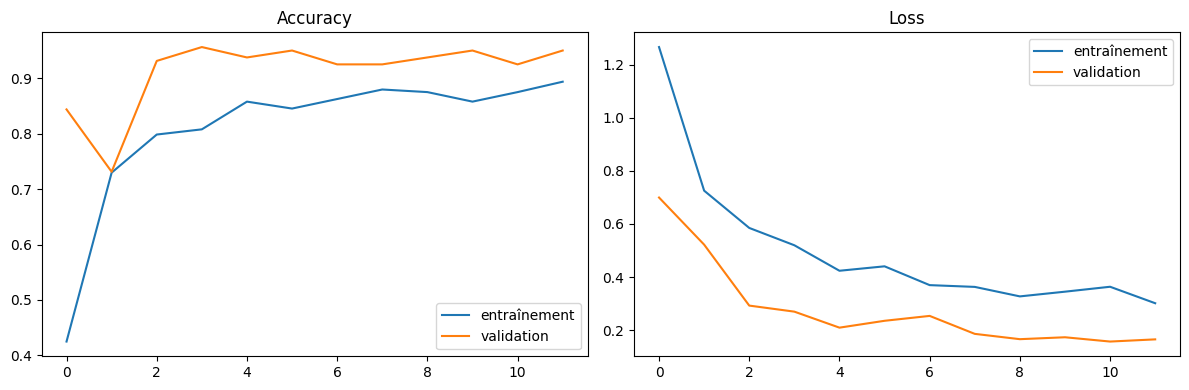

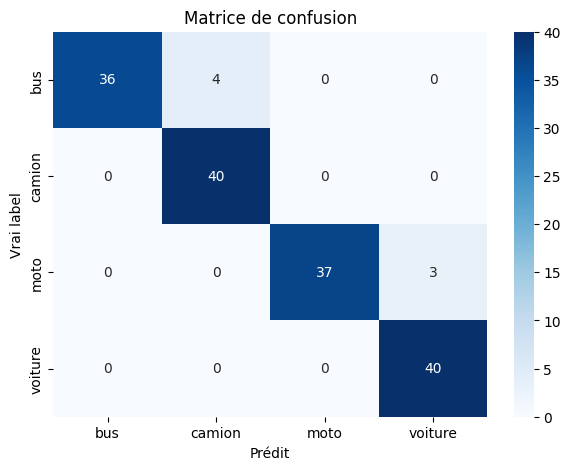

              precision    recall  f1-score   support

         bus       1.00      0.90      0.95        40
      camion       0.91      1.00      0.95        40
        moto       1.00      0.93      0.96        40
     voiture       0.93      1.00      0.96        40

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Courbes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='entraînement')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='entraînement')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig("courbes.png")
plt.show()

# Matrice de confusion
CLASSES = ["bus", "camion", "moto", "voiture"]
val_data.reset()
y_pred, y_true = [], []

for i in range(len(val_data)):
    x_batch, y_batch = val_data[i]
    preds = model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASSES,
            yticklabels=CLASSES,
            cmap='Blues')
plt.title("Matrice de confusion")
plt.ylabel("Vrai label")
plt.xlabel("Prédit")
plt.savefig("matrice_confusion.png")
plt.show()

# Rapport
print(classification_report(y_true, y_pred, target_names=CLASSES))



In [ ]:
# Sauvegarder
model.save("mon_modele_v2.keras")
print("Modèle v2 sauvegardé !")

from google.colab import files
files.download("mon_modele_v2.keras")

Modèle v2 sauvegardé !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>